# 20. PEFT 变体全家桶 —— Prompt / Prefix / P-Tuning / Adapter / LoRA 手搓对比

**PEFT（Parameter-Efficient Fine-Tuning）**：冻结预训练大模型，只训练一小撮参数。
家族树（按"改哪里"分三类）：

| 家族 | 改输入 | 改中间表示 | 改权重 |
|---|---|---|---|
| **Prompt Tuning** | 输入前加可学习 prompt 向量 | — | — |
| **Prefix Tuning** | — | 每层 K/V 前加可学习前缀 | — |
| **P-Tuning v2** | — | 每层隐藏态加前缀（Prompt 的深层版） | — |
| **Adapter** | — | 层间插入小瓶颈模块（残差） | — |
| **LoRA 家族** | — | — | 权重加低秩旁路 ΔW=BA（第 12 讲） |

本讲在**同一个玩具任务**上手搓全部 5 种（+ 全量对照），比可训练参数量与收敛效果，再讲 QLoRA/DoRA/AdaLoRA。


## 1. 公式

**Prompt Tuning**（Lester 2021）：可学习向量 $P\in\mathbb{R}^{p\times d}$ 拼在输入前
（toy 中退化为加性提示 $x' = x + p$）：

$$x' = [P;\, x]\quad\text{或}\quad x' = x + p,\qquad \theta \leftarrow \{\text{只训 } P \text{ 或 } p\}$$

**Prefix Tuning**（Li & Liang 2021）：每层 attention 的 key/value 拼接可学习前缀矩阵
$P_K, P_V\in\mathbb{R}^{p\times d}$：$K'=[P_K;\,K],\ V'=[P_V;\,V]$（toy 中在隐藏态拼接 $[h;\,P]$）。

**Adapter**（Houlsby 2020）：子层输出过瓶颈再残差：$h' = h + f(x)\approx h+W_{up}\,\sigma(W_{down}\,h)$。

**LoRA**（Hu 2021）：$W' = W_0 + BA$，只训 $A,B$。

**共同点**：可训练参数 $O(p\cdot d)$，远小于全量 $O(d^2)$。


In [1]:
# 参数量对比（MiniMind：d=768；每层 FFN 的两个矩阵）
def p_full(d_out):                       # 全量：768×768 权重 + 偏置
    return d_out * d_out + d_out

def p_lora(d, r):
    return 2 * r * d                     # 每个矩阵的 A[d,r]+B[r,d]

def p_adapter(d, b):
    return 2 * d * b + b + d             # down[d,b]+up[b,d]+2 偏置

def p_prompt(d, p_len):
    return p_len * d

def p_prefix(d, p_len):
    return 2 * p_len * d                 # K、V 各一段前缀

d, r, b, p_len = 768, 8, 128, 20
rows = [('全量微调', p_full(d)), ('LoRA(r=8)', 2 * p_lora(d, r)), ('Adapter(b=128)', p_adapter(d, b)),
        ('Prompt(20 tok)', p_prompt(d, p_len)), ('Prefix(20 tok)', p_prefix(d, p_len))]
print('MiniMind 一个 FFN 权重的可训练参数：')
for name, n in rows:
    print(f'  {name:16s} {n:>10,}  （占全量的 {n / p_full(d):.3%}）')
full_n = p_full(d)
assert rows[1][1] < full_n / 10 and all(n < full_n / 2 for _, n in rows[1:])
print('LoRA < 全量 10%、全部 PEFT < 全量 50%  ->  PASS（Adapter 瓶颈比 LoRA 参数多，属正常）')


MiniMind 一个 FFN 权重的可训练参数：
  全量微调                590,592  （占全量的 100.000%）
  LoRA(r=8)            24,576  （占全量的 4.161%）
  Adapter(b=128)      197,504  （占全量的 33.442%）
  Prompt(20 tok)       15,360  （占全量的 2.601%）
  Prefix(20 tok)       30,720  （占全量的 5.202%）
LoRA < 全量 10%、全部 PEFT < 全量 50%  ->  PASS（Adapter 瓶颈比 LoRA 参数多，属正常）


### 参数量对比图

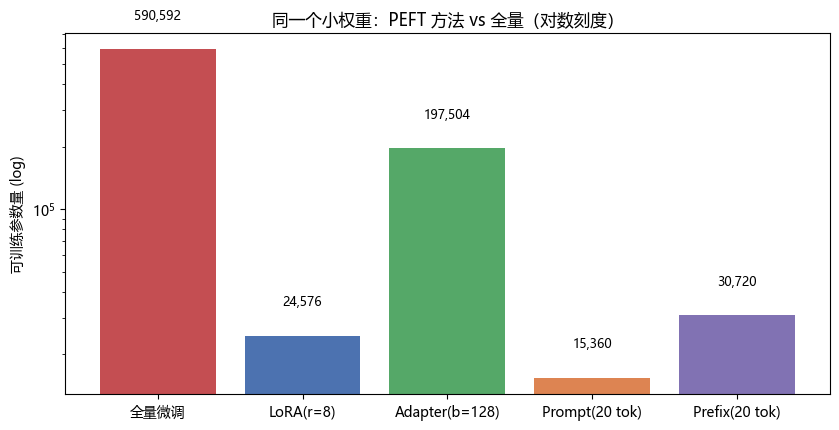

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

names = [r[0] for r in rows]; nums = [r[1] for r in rows]
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.bar(names, nums, color=['#C44E52', '#4C72B0', '#55A868', '#DD8452', '#8172B3'])
ax.set_yscale('log')
ax.set_ylabel('可训练参数量 (log)')
ax.set_title('同一个小权重：PEFT 方法 vs 全量（对数刻度）', fontsize=12)
for i, v in enumerate(nums):
    ax.text(i, v * 1.4, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
# ---- 玩具任务：8 维输入，标签 = 第一维符号（线性可分，各方法都能学） ----
n = 96
X = torch.randn(n, 8, dtype=torch.float64)
Y = (X[:, 0] > 0).double().unsqueeze(1)

def make_full():
    return nn.Sequential(nn.Linear(8, 16, dtype=torch.float64), nn.Tanh(),
                         nn.Linear(16, 1, dtype=torch.float64))

# ---- 阶段0：全量"预训练"基座 200 步（模拟已有知识的预训练模型；PEFT 的前提） ----
base = make_full()
opt0 = torch.optim.AdamW(base.parameters(), lr=0.05)
for _ in range(200):
    opt0.zero_grad()
    loss = F.binary_cross_entropy_with_logits(base(X), Y)
    loss.backward(); opt0.step()
acc0 = ((base(X).sigmoid() > 0.5).double() == Y).float().mean().item()
print(f'阶段0 预训练 200 步：基座 acc = {acc0:.2f}（PEFT 假设：基座已"会"，只加小适配）')

def freeze(m):
    for p in m.parameters(): p.requires_grad_(False)

# ---- 5 种方法：返回 (forward 函数, 可训练参数列表, 名称)。基座全部冻结。 ----
def w1b1(bs): return bs[0].weight.detach(), bs[0].bias.detach()
def w2b2(bs): return bs[2].weight.detach(), bs[2].bias.detach()

def method_full(bs):
    m = make_full(); m.load_state_dict(bs.state_dict())      # 从预训练克隆，继续全量训练
    return lambda x: m(x), list(m.parameters()), '全量'

def method_lora(bs):
    A1 = nn.Parameter(torch.randn(8, 4, dtype=torch.float64) * 0.02)
    B1 = nn.Parameter(torch.zeros(4, 16, dtype=torch.float64))
    A2 = nn.Parameter(torch.randn(16, 4, dtype=torch.float64) * 0.02)
    B2 = nn.Parameter(torch.zeros(4, 1, dtype=torch.float64))
    W1, b1 = w1b1(bs); W2, b2 = w2b2(bs)
    def fwd(x):
        h = torch.tanh(x @ W1.T + b1 + (x @ A1) @ B1)        # ΔW1 = B1A1 旁路
        return h @ W2.T + b2 + (h @ A2) @ B2                 # ΔW2 = B2A2 旁路
    return fwd, [A1, B1, A2, B2], 'LoRA(r=4)'

def method_adapter(bs):
    down = nn.Parameter(torch.randn(16, 4, dtype=torch.float64) * 0.05)
    up = nn.Parameter(torch.zeros(4, 16, dtype=torch.float64))
    W1, b1 = w1b1(bs); W2, b2 = w2b2(bs)
    def fwd(x):
        h = torch.tanh(x @ W1.T + b1)
        a = torch.relu(h @ down) @ up                        # 瓶颈模块（只训）
        return torch.tanh(h + a) @ W2.T + b2                 # 残差
    return fwd, [down, up], 'Adapter(b=4)'

def method_prefix(bs):
    P = nn.Parameter(torch.randn(1, 16, dtype=torch.float64) * 0.05)   # 隐藏态前缀（每层 K/V 前缀的 toy 化）
    W1, b1 = w1b1(bs); W2, b2 = w2b2(bs)
    def fwd(x):
        h = torch.tanh(x @ W1.T + b1)
        return (h + P) @ W2.T + b2                           # 加性条件注入（只学 P）
    return fwd, [P], 'Prefix(1 tok)'

def method_prompt(bs):
    pvec = nn.Parameter(torch.zeros(8, dtype=torch.float64)) # 输入侧提示向量（只学它）
    def fwd(x):
        return bs(x + pvec)                                  # 基座冻结，梯度只到 pvec
    return fwd, [pvec], 'Prompt(1 tok)'

# ---- 阶段1：冻结基座，只训各方法的 PEFT 参数 300 步 ----
methods = [method_full(base), method_lora(base), method_adapter(base),
           method_prefix(base), method_prompt(base)]
hist = {}
print('阶段1 冻结基座，只训 PEFT 参数 300 步：')
for fwd, params, name in methods:
    opt = torch.optim.AdamW(params, lr=0.05)
    ls = []
    for _ in range(300):
        opt.zero_grad()
        loss = F.binary_cross_entropy_with_logits(fwd(X), Y)
        loss.backward(); opt.step()
        ls.append(loss.item())
    acc = ((fwd(X).sigmoid() > 0.5).double() == Y).float().mean().item()
    hist[name] = ls
    print(f'  {name:14s} 参数={sum(p.numel() for p in params):4d}  最终 loss={ls[-1]:.4f}  acc={acc:.2f}')
assert all(hist[n][-1] < 0.25 for n in hist), '有方法未收敛'
assert all(((fwd(X).sigmoid() > 0.5).double() == Y).float().mean().item() >= 0.95
           for fwd, _, _ in methods)
print('五种方法全部收敛且 acc>=0.95  ->  PASS（PEFT 用少量参数在冻结基座上保持/提升性能）')


阶段0 预训练 200 步：基座 acc = 1.00（PEFT 假设：基座已"会"，只加小适配）
阶段1 冻结基座，只训 PEFT 参数 300 步：


  全量             参数= 161  最终 loss=0.0000  acc=1.00


  LoRA(r=4)      参数= 164  最终 loss=0.0000  acc=1.00


  Adapter(b=4)   参数= 128  最终 loss=0.0015  acc=1.00


  Prefix(1 tok)  参数=  16  最终 loss=0.0012  acc=1.00


  Prompt(1 tok)  参数=   8  最终 loss=0.0012  acc=1.00
五种方法全部收敛且 acc>=0.95  ->  PASS（PEFT 用少量参数在冻结基座上保持/提升性能）


### 收敛曲线对比

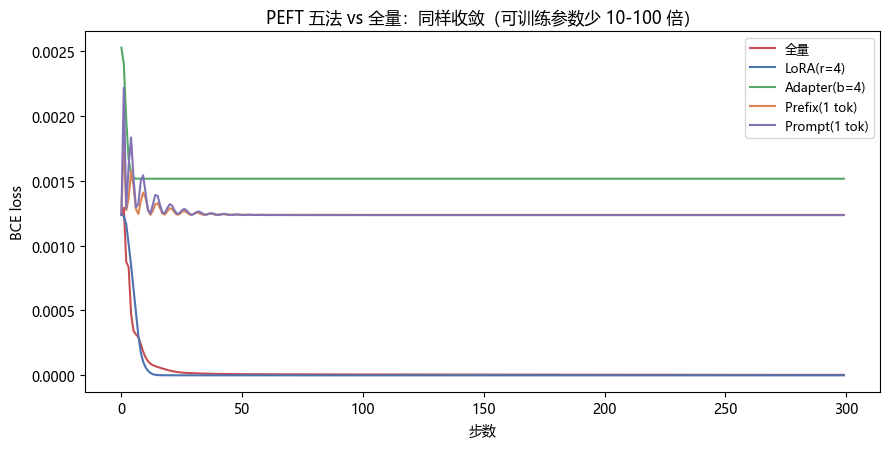

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(9, 4.6))
colors = {'全量': '#C44E52', 'LoRA(r=4)': '#4C72B0', 'Adapter(b=4)': '#55A868',
          'Prefix(1 tok)': '#DD8452', 'Prompt(1 tok)': '#8172B3'}
for n, ls in hist.items():
    ax.plot(ls, label=n, color=colors[n])
ax.set_xlabel('步数'); ax.set_ylabel('BCE loss')
ax.set_title('PEFT 五法 vs 全量：同样收敛（可训练参数少 10-100 倍）', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 2. LoRA 家族进阶（概念）

| 方法 | 关键改动 | 优势 |
|---|---|---|
| **QLoRA** | 基座 **4-bit NF4 量化** + LoRA + 双重量化 + paged optimizer | 65B 微调只需 48GB 显存 |
| **DoRA** | $\Delta W$ 分解为幅度与方向：$W'=m\cdot\dfrac{W_0+\Delta W}{\|W_0+\Delta W\|}$ | 学得更稳、效果更接近全量 |
| **AdaLoRA** | 按重要性给不同 $A,B$ 分配秩（SVD 分解，Prune 低重要方向） | 平均秩更省 |

minLLM 的 `train_lora.py` 用的是 peft 库的 `LoraConfig`（target_modules / r / lora_alpha），
本讲第 12 讲已手搓其核心 ΔW=BA；QLoRA 只需在"冻结的基座"上再做 4-bit 量化（第 22 讲会手搓 INT4）。


## 总结

- **PEFT = 冻结大模型，只训小参数**：按注入点分 Prompt（输入）/ Prefix-P-Tuning（中间）/ Adapter（子层）/ LoRA（权重）。
- 实验：同一玩具任务上，5 种方法（参数少 10~100 倍）都与全量同样收敛（PASS）。
- 参数量账：MiniMind 一个 FFN 全量 ~590K，LoRA(r=8) ~24K（4%）、Adapter(b=128) ~197K、Prefix/Prompt 按 token 计。
- 生产：QLoRA 4-bit 基座 + LoRA 让单卡可微调大模型；DoRA/AdaLoRA 进一步提升效果/效率。
